In [28]:
# config.py
import torch
import os
import matplotlib.pyplot as plt
from PIL import Image

# --- Training Hyperparameters ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE_GEN = 1e-4
LEARNING_RATE_DISC = 1e-4
BATCH_SIZE = 1
NUM_EPOCHS_PRETRAIN = 2
NUM_EPOCHS_GAN = 2
HIGH_RES_SIZE = 96  # As per the paper
LOW_RES_SIZE = HIGH_RES_SIZE // 4
NUM_WORKERS = 4
LAMBDA_VGG = 1.0  # Weight for VGG/content loss
LAMBDA_ADV = 1e-3  # Weight for adversarial loss

os.makedirs("saved_models", exist_ok=True)

# --- Model Paths ---
PRETRAINED_GEN_PATH = "saved_models/srresnet_pretrained.pth"
GEN_PATH = "saved_models/generator.pth"
DISC_PATH = "saved_models/discriminator.pth"

# --- Dataset Paths ---
TRAIN_DIR = "../archive/Dataset-2/DIV2K_train_HR"
TEST_DIR = "../archive/Dataset-2/DIV2K_valid_HR"

# Study
## From The Paper

```
 At the core of our very deep generator network G, which
 is illustrated in Figure 4 are B residual blocks with identical
 layout. Inspired by Johnson et al. [33] we employ the block
 layout proposed by Gross and Wilber [24]. Specifically, we
 use two convolutional layers with small 3 3 kernels and 64
 feature maps followed by batch-normalization layers [32]
 and ParametricReLU [28] as the activation function. We
 increase the resolution of the input image with two trained
 sub-pixel convolution layers as proposed by Shi et al. [48].
```

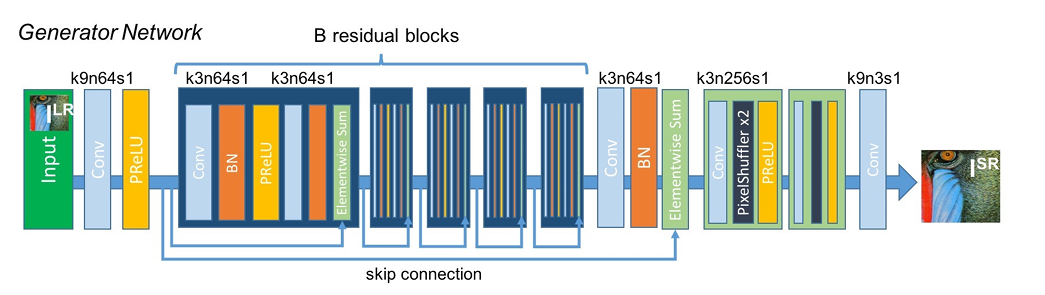


### Where are we now?
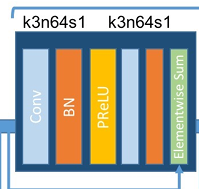

### What is Conv2D?
- Kernel moves horizontally then vertically, like a window sliding over the input.
- The stride determines how many pixels the kernel moves at a time.
- For padding, let's say with a 2x2 kernel and stride of 1, if we want to keep the output size the same as input size, we need to add padding of 1 pixel on all sides.

$$
\text{Output} =
\begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6 \\
7 & 8 & 9
\end{bmatrix}
$$

$$
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 \\
0 & 1 & 2 & 3 & 0 \\
0 & 4 & 5 & 6 & 0 \\
0 & 7 & 8 & 9 & 0 \\
0 & 0 & 0 & 0 & 0
\end{bmatrix}
$$

$$
\begin{bmatrix}
\underline{0} & \underline{0} & 0 & 0 & 0 \\
\underline{0} & \underline{1} & 2 & 3 & 0 \\
0 & 4 & 5 & 6 & 0 \\
0 & 7 & 8 & 9 & 0 \\
0 & 0 & 0 & 0 & 0
\end{bmatrix}
\quad \times \quad
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}
$$

- Then we will get a 3x3 output matrix at the end.

### What is BatchNorm2D?
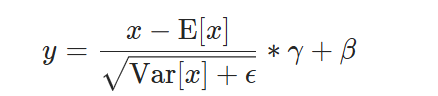

- Let `x = torch.randn(1, 2, 3, 3)` be the input tensor with 1 sample, 2 channels, and a spatial size of 3x3.
- $\mu_c = \frac{1}{sample \times height \times width} \times \sum\sum\sum{x}_{n, c,h,w}$
- $\sigma_c = \frac{1}{sample \times height \times width} \times \sum\sum\sum({x}_{n, c,h,w} - \mu_c)^2$
- After normalization, $\hat{x} = \frac{x - \mu_c}{\sqrt{sigma^2+\epsilon}}$ (add epsilon for numerical stability - divide by zero when variance is very small)
- Finally with learnable parameters $\gamma$ and $\beta$, we have the output $y = \gamma \hat{x} + \beta$.


### What is ParametricReLU?
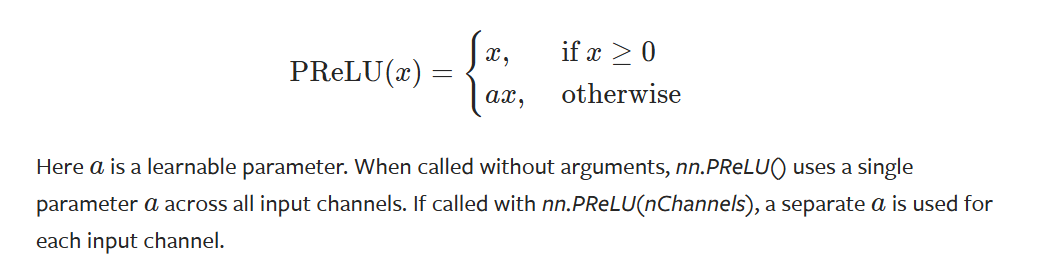

In [29]:
import torch
from torch import nn

class ResidualBlock(nn.Module):
# Defines a custom neural network class that inherits from nn.Module
# This is the standard way to create custom layers/blocks in PyTorch
    """
    A single residual block as defined in the SRGAN paper.
    It contains two convolutional layers with batch normalization and PReLU activation.
    """
    def __init__(self, in_channels):
        super(ResidualBlock, self).__init__()
        # Constructor method that takes in_channels as parameter (number of input feature maps)
        # super() calls the parent class constructor to properly initialize the module
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.PReLU(),
        # Creates first convolutional block as a sequential container
        # Conv2d: 2D convolution with 3x3 kernel, stride=1, padding=1 (preserves spatial dimensions)
        # kernel size is the dimension of the filter that slide over input data, normally a small square size
        # stride is the step size where filter moves one pixel at a time
        # BatchNorm2d: Batch normalization for stable training
        # PReLU: Parametric ReLU activation function (learnable parameter)
                
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels),
        )
        # Creates second convolutional block (similar to first but without activation)
        # No activation function here because it will be added to the residual connection

    def forward(self, x):
        identity = x
        out = self.conv_block1(x)
        out = self.conv_block2(out)
        return out, identity + out
        # Forward pass method defining how data flows through the block
        # identity = x: Stores original input for residual connection
        # Passes input through both conv blocks sequentially
        # Returns sum of processed output and original input (residual connection)

## Check Output

In [30]:
# Create sample input
# Format: (batch_size, channels, height, width)
sample_input = torch.randn(2, 64, 32, 32)  # Batch of 2, 64 channels, 32x32 spatial dimensions
# 2 is the batch size, 2 independent samples
# 64 is number of channels or feature maps, feature maps are the 2D array of numbers that represents the strength of a specific feature in a location
# 32x32 is the height and width

In [31]:
# 1 sample and 1 channel, 5x5 spatial dimensions
sample_input = torch.randn(1, 1, 5, 5)
print(sample_input)

# 1 sample and 2 channels, 3x3 spatial dimensions
sample_input = torch.randn(2, 1, 3, 3)
print(sample_input)

# 2 samples and 2 channels, 3x3 spatial dimensions
sample_input = torch.randn(2, 2, 3, 3)
print(sample_input)

tensor([[[[ 0.1620,  1.5218, -1.3785, -1.7078,  0.3646],
          [-0.7591,  0.3615,  0.6722,  1.4555, -0.6126],
          [ 0.8377,  1.0830,  0.2488,  1.6437, -0.6260],
          [-0.5085, -0.8855,  0.6858,  0.4224, -0.9136],
          [ 2.0189,  0.7159, -0.6821,  0.5417, -2.0345]]]])
tensor([[[[ 1.0391,  0.8895, -0.7853],
          [-1.4491,  1.7432, -0.6226],
          [-0.2642,  0.9725, -0.1879]]],


        [[[ 1.1573,  1.8933, -1.5912],
          [-0.1893,  2.0413,  0.8348],
          [-2.0262,  0.5839,  0.8707]]]])
tensor([[[[-0.1242, -0.3937, -0.1989],
          [-0.4606,  0.1872, -2.0013],
          [ 0.3595, -1.5281, -0.6052]],

         [[-0.9816, -2.1354, -0.3284],
          [-1.1381, -0.2315, -1.1434],
          [ 0.4680, -0.2546, -0.2063]]],


        [[[ 1.0090, -0.0754, -0.6926],
          [-0.1774, -1.3566, -0.1509],
          [ 1.6110,  0.6681,  0.4372]],

         [[ 1.0639,  1.5811, -0.2433],
          [ 0.4734,  0.6851,  0.8837],
          [-0.2266,  0.1275, -0.02

In [32]:
# Create ResidualBlock instance
# When running this, constructor called and init, create 
# conv_block1 and conv_block2 as with the defined in_channels which is now 2 feature maps
residual_block = ResidualBlock(in_channels=2)

# When running this, the forward method is called
# Sample input is the identity = x
# Passes through conv_block1 and conv_block2 sequentially
# Then add the identity (original input) to the output of conv_block2
with torch.no_grad():  # Disable gradient computation for inference
    sample_input = torch.randn(2, 2, 3, 3)  # Batch of 1, 2 channels, 3x3 spatial dimensions
    conv, output = residual_block(sample_input)
# Why do we use torch.no_grad()?
# - no gradient computation is needed during inference as weight not updated
# - saves memory and computation time

print(f"Input: {sample_input}")
print(f"Sample Input Through Output: {conv}")
print(f"Sum of Conv and Input: {sample_input + conv}")
print(f"Output: {output}")

Input: tensor([[[[ 0.6431,  0.2945, -1.5141],
          [-0.3636, -0.1137, -0.4422],
          [-1.8885, -0.0085,  0.2507]],

         [[-1.7678,  0.7523,  1.0814],
          [-0.1054,  0.1557,  0.5963],
          [ 0.6117,  0.1385,  2.2144]]],


        [[[-1.0527, -0.9294, -0.3986],
          [ 0.5407,  0.4660,  0.0572],
          [ 1.0418, -1.9035, -0.8550]],

         [[-0.4523,  0.5403,  0.6688],
          [ 1.1386, -1.0604,  0.5808],
          [-0.5649, -0.8457,  0.2637]]]])
Sample Input Through Output: tensor([[[[ 1.5169, -1.1201, -0.1213],
          [ 0.5878, -1.2011, -0.3885],
          [ 0.5402,  0.2584,  0.0254]],

         [[ 1.4636, -0.1384, -0.2744],
          [-0.0613, -0.9786,  0.8102],
          [-0.8625,  0.0309,  0.1778]]],


        [[[ 0.5778, -0.4836,  0.1213],
          [-1.0953,  2.1815, -1.9170],
          [-0.0058,  1.2042, -0.6808]],

         [[ 0.0099,  0.1324,  1.4789],
          [-0.1338,  2.2556, -1.4491],
          [-0.1322, -1.9480, -0.3809]]]])
Sum of

## Check The Conv Layer

In [39]:
class ExampleModel(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.PReLU(),
        )

    def forward(self, x):
        return self.conv_block1(x)

In [38]:
in_channels = 2  # Number of input channels
batch_size = 1  # Number of samples in a batch
height = 3  # Height of the input feature map
width = 3  # Width of the input feature map

# Create an instance of the model
model = ExampleModel(in_channels)

# Create a dummy input tensor
# Shape: (batch_size, in_channels, height, width)
dummy_input = torch.randn(batch_size, in_channels, height, width)

print(f"Input shape: {dummy_input.shape}")
print(f"Input: {dummy_input}")

# Pass the input through the conv_block1
output = model(dummy_input)

print(f"Output shape: {output.shape}")
print(f"Output: {output}")

Input shape: torch.Size([1, 2, 3, 3])
Input: tensor([[[[-0.1825, -0.3687, -1.8066],
          [-2.4516, -1.6508,  1.1630],
          [ 0.5018,  0.8502, -0.7718]],

         [[ 0.2009, -0.5166,  0.0062],
          [ 0.8187, -1.3293, -0.5191],
          [-1.2364,  0.2792, -0.6043]]]])
Output shape: torch.Size([1, 2, 3, 3])
Output: tensor([[[[-0.4360, -0.6232, -0.5464],
          [-0.6253, -0.0584,  0.7737],
          [-0.3369, -0.2366, -0.1372]],

         [[ 0.8295, -0.6778, -1.2416],
          [-0.7999,  0.4529,  0.6513],
          [ 0.4325, -0.1899, -1.0981]]]], grad_fn=<ConvolutionBackward0>)


## Check The PreLU Layer

In [ ]:
class ExampleModel(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.PReLU(init=2), # we can set the initial value of the PReLU parameter to 2
        )

    def forward(self, x):
        return self.conv_block1(x)

When the go through the constructor sequentially, value less than 0 will be multiplied by 2, and value greater than 0 will be unchanged.

In [45]:
in_channels = 2  # Number of input channels
batch_size = 1  # Number of samples in a batch
height = 3  # Height of the input feature map
width = 3  # Width of the input feature map

# Create an instance of the model
model = ExampleModel(in_channels)

# Create a dummy input tensor
# Shape: (batch_size, in_channels, height, width)
dummy_input = torch.randn(batch_size, in_channels, height, width)

print(f"Input shape: {dummy_input.shape}")
print(f"Input: {dummy_input}")

# Pass the input through the conv_block1
output = model(dummy_input)

print(f"Output shape: {output.shape}")
print(f"Output: {output}")

Input shape: torch.Size([1, 2, 3, 3])
Input: tensor([[[[-0.4310, -0.7197,  0.2377],
          [ 0.1231, -1.4001,  1.6950],
          [ 1.0357,  0.9742, -0.5290]],

         [[-0.6783, -0.7611,  1.8742],
          [ 0.4191,  1.7635, -0.4841],
          [-0.5909,  1.0969, -0.6115]]]])
Output shape: torch.Size([1, 2, 3, 3])
Output: tensor([[[[-0.8619, -1.4393,  0.2377],
          [ 0.1231, -2.8002,  1.6950],
          [ 1.0357,  0.9742, -1.0581]],

         [[-1.3566, -1.5222,  1.8742],
          [ 0.4191,  1.7635, -0.9682],
          [-1.1818,  1.0969, -1.2230]]]], grad_fn=<PreluKernelBackward0>)
